In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path

In [6]:
RAW = Path("../data/raw")

ORDER_DATES = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders    = pd.read_csv(RAW / "olist_orders_dataset.csv", parse_dates=ORDER_DATES)
items     = pd.read_csv(RAW / "olist_order_items_dataset.csv")
sellers   = pd.read_csv(RAW / "olist_sellers_dataset.csv")
customers = pd.read_csv(RAW / "olist_customers_dataset.csv")
reviews   = pd.read_csv(RAW / "olist_order_reviews_dataset.csv")

# Rebuild delivery — same as notebook 1.1
delivery = (
    orders
    .merge(items[["order_id","seller_id"]], on="order_id", how="left")
    .merge(sellers[["seller_id","seller_state"]], on="seller_id", how="left")
    .merge(customers[["customer_id","customer_state"]], on="customer_id", how="left")
)
delivery = delivery[delivery["order_status"] == "delivered"].copy()

## Score distribution

Bad review rate: 14.7%


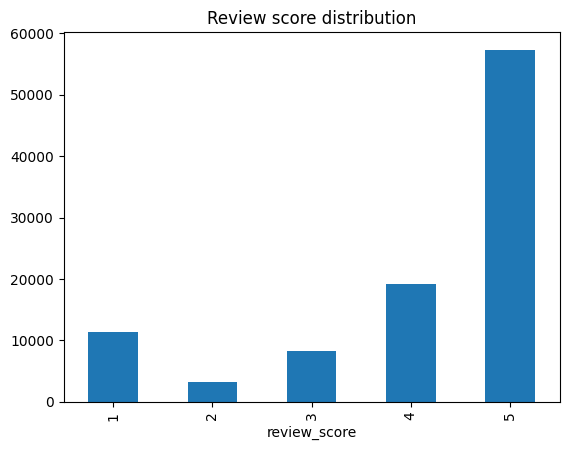

In [7]:
reviews["review_score"].value_counts().sort_index().plot( kind="bar", title="Review score distribution") 
plt.savefig("../reports/figures/1.2-review-score-dist.png", dpi=150) # Define the ML target: bad review = score of 1 or 2 
reviews["is_bad_review"] = reviews["review_score"] <= 2 
print(f"Bad review rate: {reviews['is_bad_review'].mean():.1%}")


## Review score vs delivery delay — the key relationship

Avg review score — on time vs late:
is_late
False    4.207432
True     2.256468
Name: review_score, dtype: float64


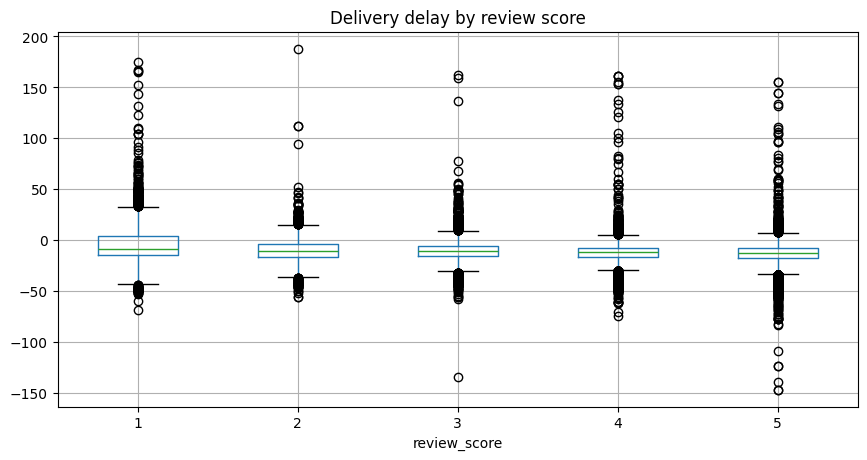

In [8]:
delivery["delivery_delay_days"] = (pd.to_datetime(delivery["order_delivered_customer_date"]) - pd.to_datetime(delivery["order_estimated_delivery_date"])).dt.days
delivery["is_late"] = delivery["delivery_delay_days"] > 0

rev_del = reviews.merge( delivery[["order_id","delivery_delay_days","is_late"]], on="order_id", how="left") 
avg_score = rev_del.groupby("is_late")["review_score"].mean() 
print("Avg review score — on time vs late:") 
print(avg_score) 
rev_del.boxplot(column="delivery_delay_days", by="review_score", figsize=(10,5)) 
plt.suptitle("") 
plt.title("Delivery delay by review score") 
plt.savefig("../reports/figures/1.2-delay-vs-score.png", dpi=150)

## Time from delivery to review — how fast do customers respond?

In [9]:
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"]) 
orders_ts = orders[["order_id","order_delivered_customer_date"]] 
rev_time = reviews.merge(orders_ts, on="order_id") 
rev_time["days_to_review"] = ( rev_time["review_creation_date"] - rev_time["order_delivered_customer_date"] ).dt.days 
print(rev_time["days_to_review"].describe())

count    96359.000000
mean        -0.541423
std          4.676891
min       -187.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        106.000000
Name: days_to_review, dtype: float64


## Basic text analysis on bad reviews

In [11]:
bad = reviews[reviews["is_bad_review"] == True].copy()
bad_text = bad["review_comment_message"].dropna()
bad["comment_length"] = bad["review_comment_message"].fillna("").str.len()
print("Bad reviews with comments:", bad_text.shape[0])
print("Avg comment length:", bad["comment_length"].mean().round(1))
print(bad_text.sample(5).tolist())

Bad reviews with comments: 10890
Avg comment length: 74.2
['Não é possível tanta falta de atenção uma demora tremenda para receber o produto pra quando chegar vim errado e agora o q faço ???', 'produto entregue diferente do que foi comprado,não recomendo o vendedor.', 'consta que está em transporte desde o dia\r\n25/03/2018 \r\n11:16 \r\nLONDRINA / PR para RIO DE JANEIRO / RJ\r\nespero recebe uma resposta ao meu pedido', 'Adquiri 2 Suportes e apenas recebi 1 e foi faturado os dois, porem chegou apenas o Transbike para bicicletas Aro 29. O Suporte De Parede Para Sua Bicicleta Atrio não chegou.', 'A resistência deveria vir uma 110 e outra 220.\r\nVieram duas 110.\r\nEssa foi a razão de meu desapontamento.\r\nE como corrigir?']
